# Imports and Setup 

In [35]:
import cv2
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ensure matplotlib plots are displayed inline within the Jupyter Notebook
%matplotlib inline

print("✅ All libraries imported successfully! Ready for the next step.")

✅ All libraries imported successfully! Ready for the next step.


# Define the SVM Classifier & Feature Extraction Logic

In [36]:
class TrafficSignSVMClassifier:
    def __init__(self, dataset_path):
        # Initialize SVM with RBF kernel
        self.model = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
        self.target_size = (64, 64) 
        self.dataset_path = dataset_path
        self.classes = []     
        
        # ================= NEW: Load Real Class Names =================
        self.class_names = {}
        # Check current directory first, then dataset directory
        csv_path = "labels.csv"
        if not os.path.exists(csv_path):
            csv_path = os.path.join(self.dataset_path, "labels.csv")
            
        if os.path.exists(csv_path):
            try:
                import pandas as pd
                df = pd.read_csv(csv_path)
                # Map string ID to actual Name (e.g., "0" -> "Speed limit (5km/h)")
                self.class_names = {str(row['ClassId']): row['Name'] for _, row in df.iterrows()}
                print(f"✅ Successfully loaded {len(self.class_names)} real class names from {csv_path}!")
            except Exception as e:
                print(f"⚠️ Could not load {csv_path}: {e}")
        else:
            print("⚠️ labels.csv not found. Defaulting to 'Class X' naming.")
        # ===============================================================

    def extract_color_histogram(self, img_bgr, bins=(8, 8, 8)):
        """Converts image to HSV space and calculates a 3D color histogram."""
        hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        cv2.normalize(hist, hist)
        return hist.flatten()

    def extract_combined_features(self, image):
        """Extracts both Color Histogram and HOG, then concatenates them."""
        color_hist_vector = self.extract_color_histogram(image)
        img_resized = cv2.resize(image, self.target_size)
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        hog_vector = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)
        combined_features = np.hstack([color_hist_vector, hog_vector])
        return combined_features

    def load_training_data(self):
        """Loads all training images directly from the TRAIN folder."""
        X_train, y_train, paths_train = [], [], []
        train_dir = os.path.join(self.dataset_path, 'TRAIN')
        if not os.path.exists(train_dir): 
            return np.array(X_train), np.array(y_train), paths_train

        folder_names = [f for f in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, f))]
        self.classes = sorted([str(int(f)) for f in folder_names]) 
        
        for class_folder in folder_names:
            class_path = os.path.join(train_dir, class_folder)
            class_id_str = str(int(class_folder))
            
            img_list = os.listdir(class_path) 
            
            for img_name in img_list:
                img_path = os.path.join(class_path, img_name)
                image = cv2.imread(img_path)
                if image is not None:
                    X_train.append(self.extract_combined_features(image))
                    y_train.append(class_id_str)
                    paths_train.append(img_path) 
                    
        return np.array(X_train), np.array(y_train), paths_train

    def load_testing_data(self):
        """Deep recursive loader: finds images anywhere inside the TEST folder structure."""
        X_test, y_test, paths_test = [], [], []
        test_dir = os.path.join(self.dataset_path, 'TEST') 
        
        if not os.path.exists(test_dir): 
            print(f"❌ Error: Test directory '{test_dir}' not found!")
            return np.array(X_test), np.array(y_test), paths_test

        print(f"📂 Recursively scanning all folders inside '{test_dir}' for test images...")
        image_count = 0
        
        # os.walk goes through ALL nested folders automatically
        for root, dirs, files in os.walk(test_dir):
            for file_name in files:
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(root, file_name)
                    image = cv2.imread(img_path)
                    
                    if image is not None:
                        try:
                            # Extract class prefix (e.g., '000_1_00.png' -> '0')
                            class_prefix = file_name.split('_')[0]
                            class_id_str = str(int(class_prefix))
                        except ValueError:
                            # Skip files that don't have a numeric prefix
                            continue
                            
                        X_test.append(self.extract_combined_features(image))
                        y_test.append(class_id_str)
                        paths_test.append(img_path)
                        image_count += 1
                        
        print(f"📄 Success! Found and extracted {image_count} images from the deep folder structure.")
        return np.array(X_test), np.array(y_test), paths_test

# Load Data and Extract Features

In [37]:
import time

# Ensure your dataset folder is named 'dataset' and is in the same directory
DATASET_PATH = "dataset" 
svm_classifier = TrafficSignSVMClassifier(DATASET_PATH)

print("⏳ Extracting features for the training set (from TRAIN folder)...")
start_train_extract = time.time()

# Unpack 3 values: features, labels, and image paths
X_train, y_train, train_paths = svm_classifier.load_training_data()
print(f"✅ Training set extraction complete! Total: {len(X_train)} images. Time taken: {time.time() - start_train_extract:.2f} seconds")

# CHANGED: Print statement updated to say TEST folder
print("\n⏳ Extracting features for the testing set (from TEST folder)...")
start_test_extract = time.time()

# Unpack 3 values: features, labels, and image paths
X_test, y_test, test_paths = svm_classifier.load_testing_data() 
print(f"✅ Testing set extraction complete! Total: {len(X_test)} images. Time taken: {time.time() - start_test_extract:.2f} seconds")

✅ Successfully loaded 58 real class names from labels.csv!
⏳ Extracting features for the training set (from TRAIN folder)...
✅ Training set extraction complete! Total: 4170 images. Time taken: 21.80 seconds

⏳ Extracting features for the testing set (from TEST folder)...
📂 Recursively scanning all folders inside 'dataset\TEST' for test images...
📄 Success! Found and extracted 84 images from the deep folder structure.
✅ Testing set extraction complete! Total: 84 images. Time taken: 0.44 seconds


# Train, Evaluate, and Visualize

⏳ Starting SVM model training...
✅ Training complete! Time taken: 8.94 seconds

TESTING RESULT — SUPPORT VECTOR MACHINE (SVM)
Accuracy          : 1.0000
F1 (weighted)     : 1.0000
Precision         : 1.0000
Recall            : 1.0000

Classification report:
                              precision    recall  f1-score   support

        Speed limit (5km/h)       1.00      1.00      1.00         4
       Speed limit (15km/h)       1.00      1.00      1.00         2
       Speed limit (30km/h)       1.00      1.00      1.00         2
       Speed limit (40km/h)       1.00      1.00      1.00         1
       Speed limit (50km/h)       1.00      1.00      1.00         1
       Speed limit (60km/h)       1.00      1.00      1.00         2
       speed limit (80km/h)       1.00      1.00      1.00         1
   Dont Go straight or left       1.00      1.00      1.00         1
           Dont Go straight       1.00      1.00      1.00         1
               Dont Go Left       1.00      1.00  

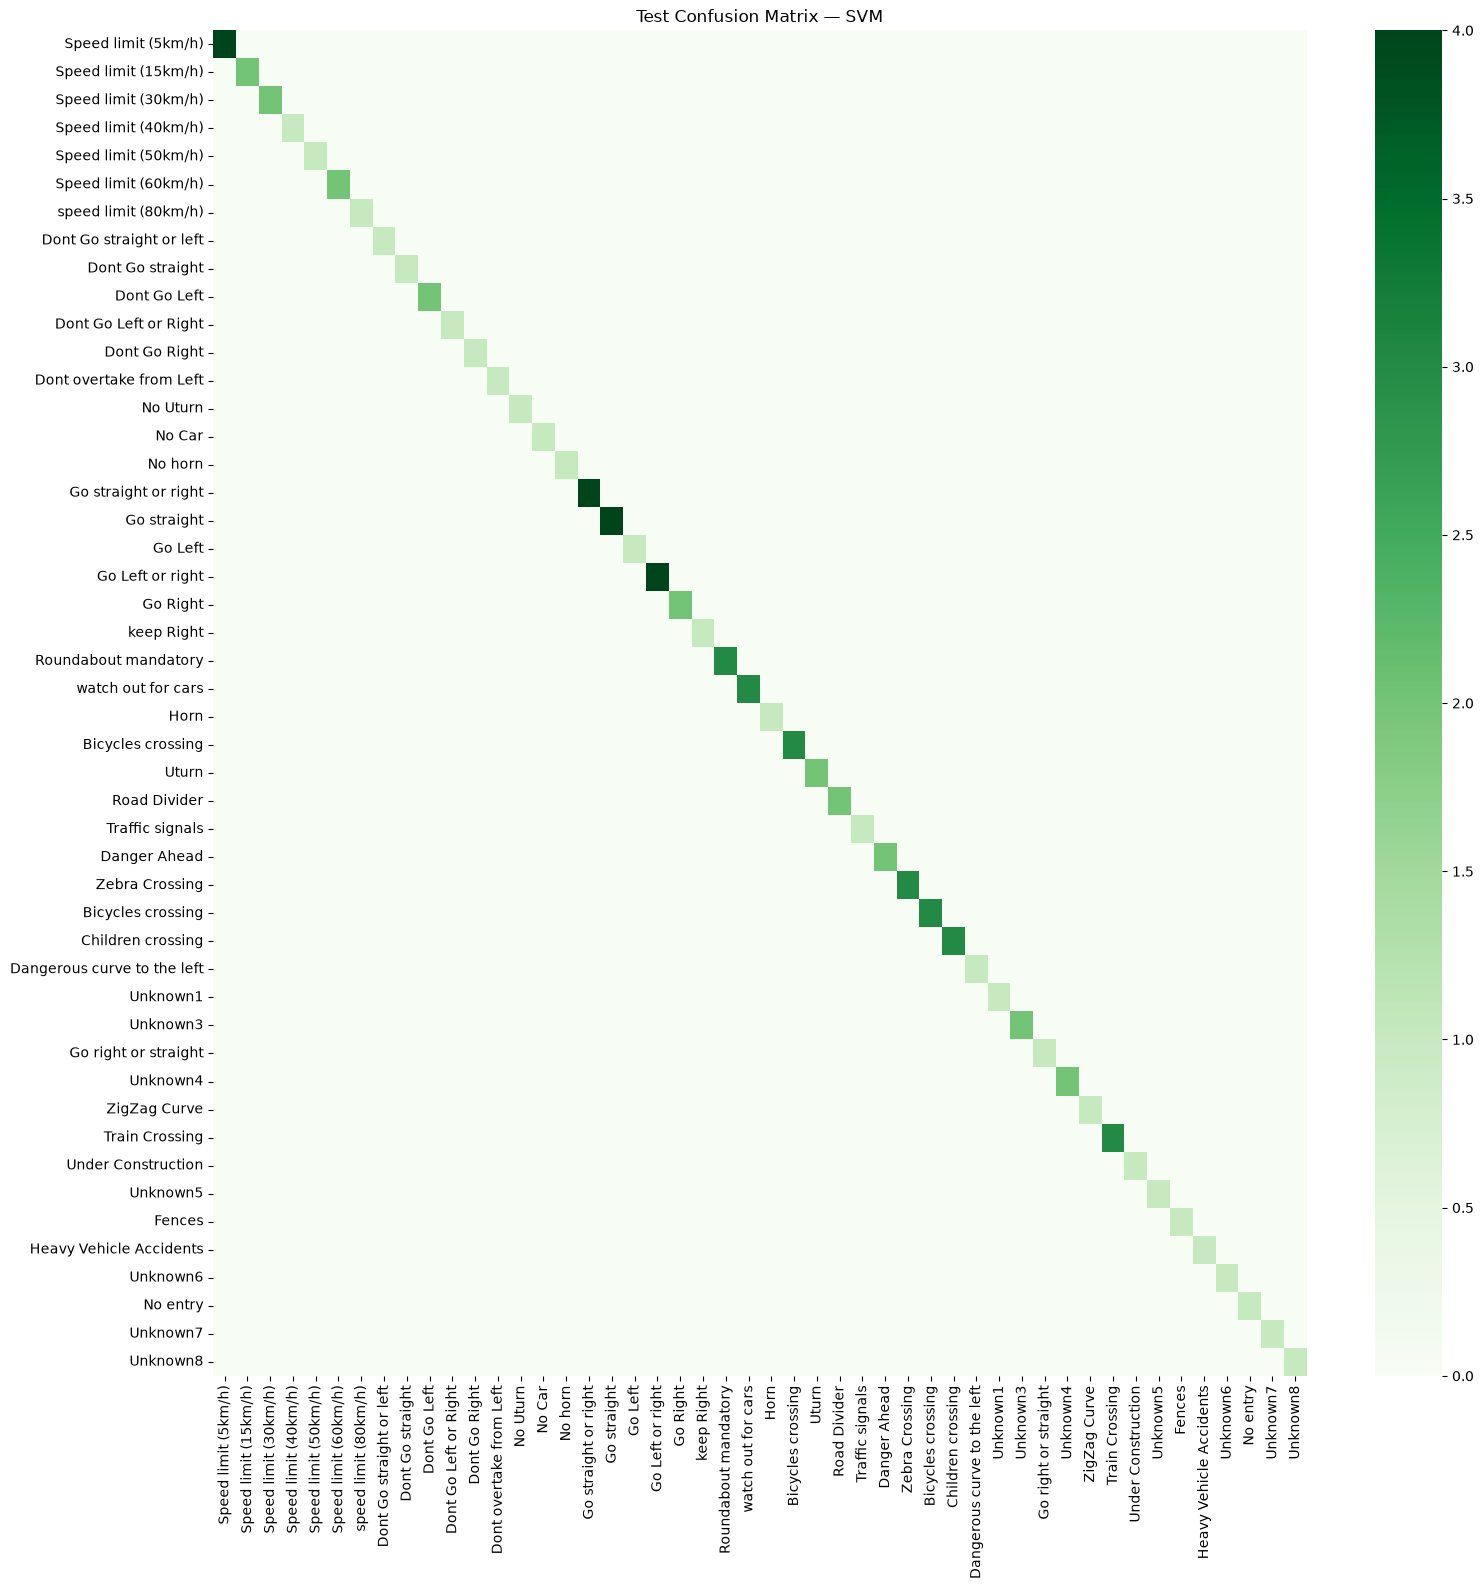


📊 Generating Training Results Gallery...
📸 Exported gallery image to: result/training_results_10_final.png


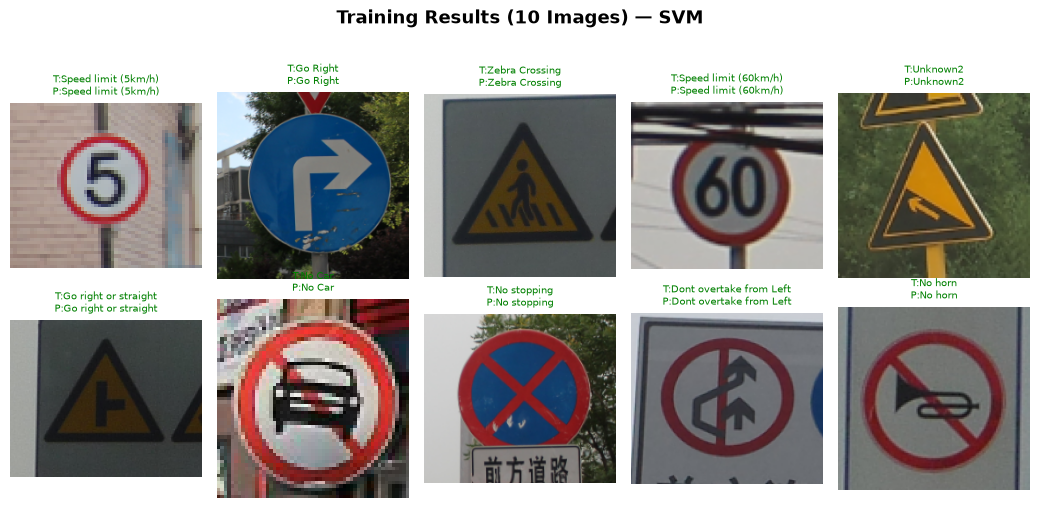


📊 Generating Testing Gallery for ALL 84 Test Images...
📸 Exported gallery image to: result/all_testing_results_svm_final.png


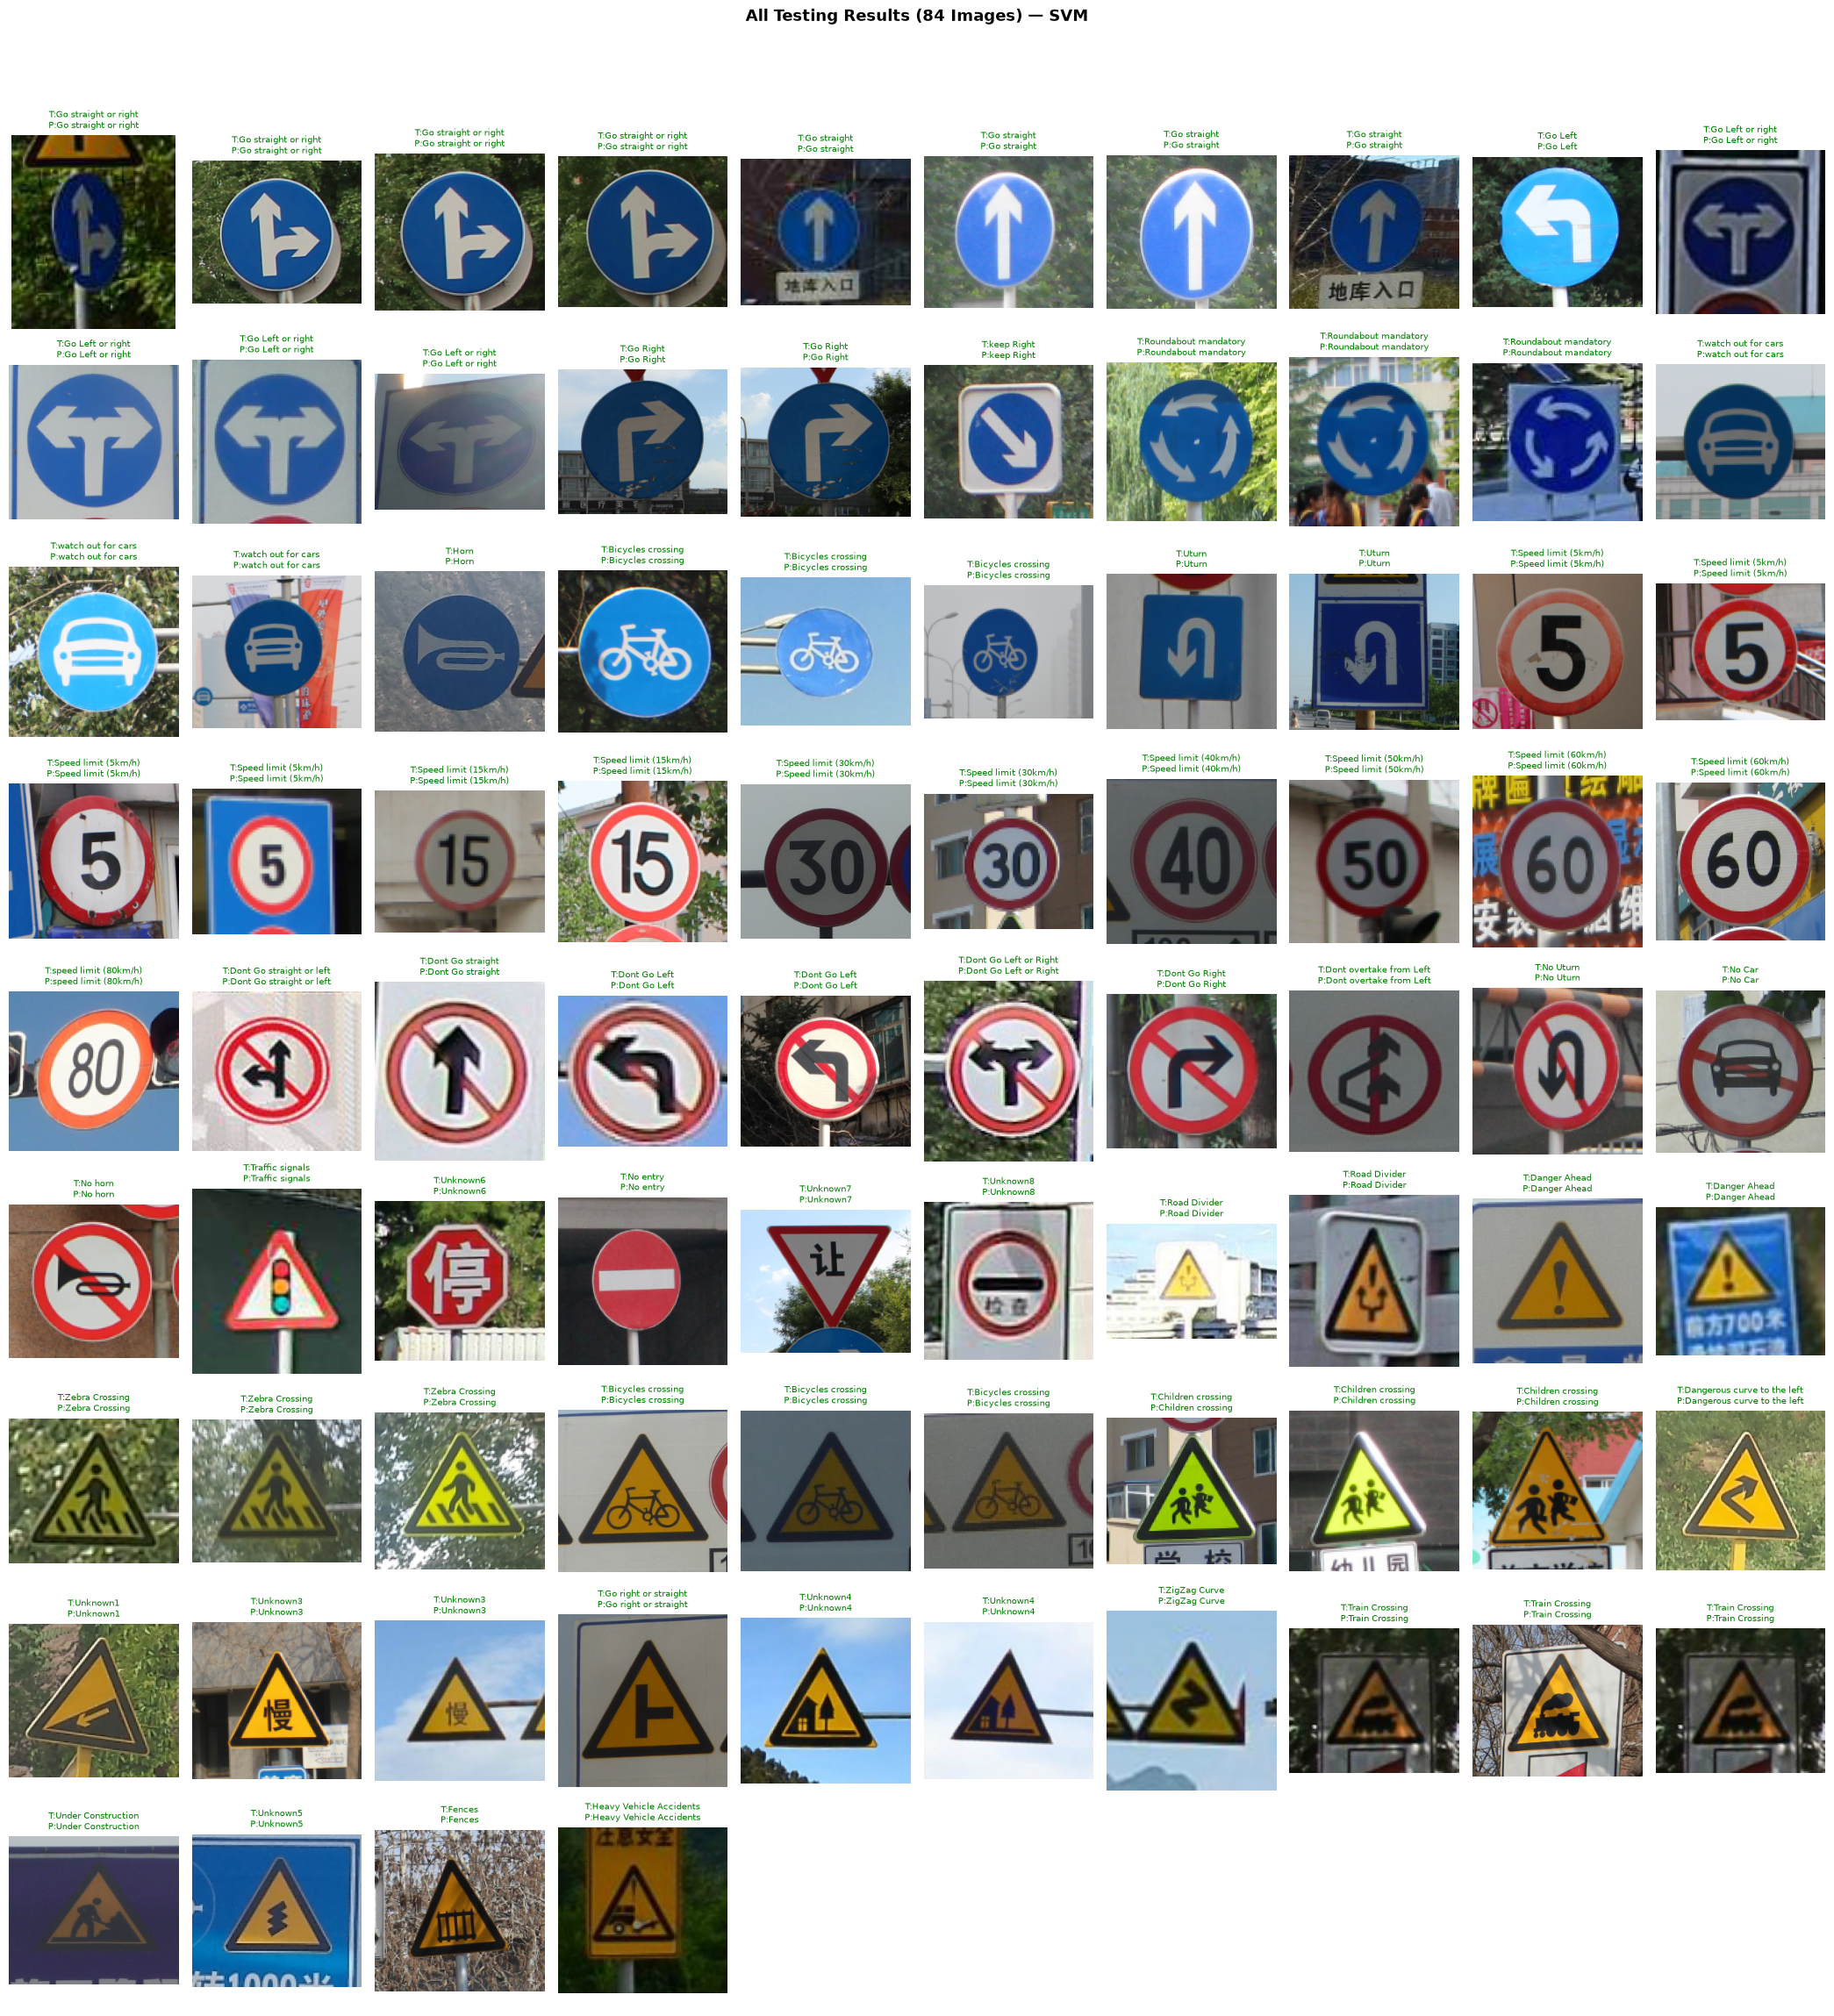

In [38]:
from sklearn.metrics import classification_report
import os
import numpy as np

# ================= Create result directory =================
RESULT_DIR = "result"
if not os.path.exists(RESULT_DIR):
    os.makedirs(RESULT_DIR)
    print(f"📁 Created directory '{RESULT_DIR}' for exporting PNGs.")

def display_image_grid(indices, image_paths, y_true, y_pred, class_id_to_name, title, filename_prefix, color='green', max_cols=10, cell_size=2.1):
    """Displays a grid of images and exports it as a PNG file to the result folder."""
    n = len(indices)
    if n == 0:
        print(f"[{title}] Nothing to display.")
        return

    n_cols = min(max_cols, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * cell_size, n_rows * (cell_size + 0.5)))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax_i, idx in enumerate(indices):
        img = cv2.cvtColor(cv2.imread(image_paths[idx]), cv2.COLOR_BGR2RGB)
        axes[ax_i].imshow(img)
        
        true_id, pred_id = str(y_true[idx]), str(y_pred[idx])
        true_name = class_id_to_name.get(true_id, f"Class {true_id}")
        pred_name = class_id_to_name.get(pred_id, f"Class {pred_id}")
        
        text_color = 'green' if true_id == pred_id else 'red'
        
        axes[ax_i].set_title(f"T:{true_name}\nP:{pred_name}", fontsize=7, color=text_color)
        axes[ax_i].axis('off')

    for ax_i in range(n, len(axes)):
        axes[ax_i].axis('off')

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # 🌟 FIXED: Using forward slashes and adding a suffix to bypass Windows path bugs & file locks
    save_path = f"{RESULT_DIR}/{filename_prefix}_final.png"
    
    plt.savefig(save_path, dpi=150)
    print(f"📸 Exported gallery image to: {save_path}")
    plt.show()

# ================= Training & Evaluation =================
if len(X_train) > 0 and len(X_test) > 0:
    print("⏳ Starting SVM model training...")
    start_train = time.time()
    svm_classifier.model.fit(X_train, y_train)
    print(f"✅ Training complete! Time taken: {time.time() - start_train:.2f} seconds\n")
    
    start_inference = time.time()
    y_pred = svm_classifier.model.predict(X_test)
    elapsed = time.time() - start_inference
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    print("=" * 90)
    print("TESTING RESULT — SUPPORT VECTOR MACHINE (SVM)")
    print("=" * 90)
    print(f"Accuracy          : {acc:.4f}")
    print(f"F1 (weighted)     : {f1:.4f}")
    print(f"Precision         : {prec:.4f}")
    print(f"Recall            : {rec:.4f}")
    
    all_labels = sorted(list(set(y_test) | set(y_pred)), key=lambda x: int(x))
    target_names = [svm_classifier.class_names.get(c, f"Class {c}") for c in all_labels]
    
    print("\nClassification report:\n",
          classification_report(y_test, y_pred, labels=all_labels,
                                target_names=target_names, zero_division=0))

    # Confusion Matrix
    cm_test = confusion_matrix(y_test, y_pred, labels=all_labels)
    side = min(0.35 * len(all_labels) + 3, 16)
    plt.figure(figsize=(side, side))
    sns.heatmap(cm_test, cmap='Greens', xticklabels=target_names, yticklabels=target_names)
    plt.title('Test Confusion Matrix — SVM')
    plt.tight_layout()
    
    # 🌟 FIXED: Using forward slashes for confusion matrix too
    cm_save_path = f"{RESULT_DIR}/confusion_matrix_svm_final.png"
    plt.savefig(cm_save_path, dpi=150)
    plt.show()

    # 1. Training Gallery
    print("\n📊 Generating Training Results Gallery...")
    y_train_arr = np.array(y_train)
    chosen_train = np.random.choice(len(y_train_arr), size=min(10, len(y_train_arr)), replace=False)
    display_image_grid(
        range(len(chosen_train)), [train_paths[i] for i in chosen_train], 
        [y_train_arr[i] for i in chosen_train], svm_classifier.model.predict([X_train[i] for i in chosen_train]), 
        svm_classifier.class_names, "Training Results (10 Images) — SVM", "training_results_10", max_cols=5 
    )

    # 2. Testing Gallery (ALL 84 Images)
    y_test_arr = np.array(y_test)
    print(f"\n📊 Generating Testing Gallery for ALL {len(y_test_arr)} Test Images...")
    all_test_idx = np.arange(len(y_test_arr))
    display_image_grid(
        all_test_idx, test_paths, y_test_arr, np.array(y_pred), svm_classifier.class_names,
        f"All Testing Results ({len(y_test_arr)} Images) — SVM", "all_testing_results_svm", max_cols=10  
    )

# Export Individual Images

In [39]:
import cv2
import os
import numpy as np

# ================= Create directory for individual images =================
INDIVIDUAL_DIR = os.path.join("result", "individual_predictions")
if not os.path.exists(INDIVIDUAL_DIR):
    os.makedirs(INDIVIDUAL_DIR)

print(f"⏳ Exporting {len(test_paths)} individual images... Please wait.")

for i in range(len(test_paths)):
    original_path = test_paths[i]
    filename = os.path.basename(original_path)
    
    true_id = str(y_test[i])
    pred_id = str(y_pred[i])
    
    true_name = svm_classifier.class_names.get(true_id, f"Class {true_id}")
    pred_name = svm_classifier.class_names.get(pred_id, f"Class {pred_id}")
    
    img = cv2.imread(original_path)
    if img is None:
        continue
        
    img_resized = cv2.resize(img, (200, 200))
    canvas = np.ones((280, 200, 3), dtype=np.uint8) * 255
    canvas[80:280, 0:200] = img_resized
    
    text_color_true = (0, 0, 0)
    text_color_pred = (0, 200, 0) if true_id == pred_id else (0, 0, 255) 
    
    cv2.putText(canvas, f"T: {true_name}", (5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.40, text_color_true, 1, cv2.LINE_AA)
    cv2.putText(canvas, f"P: {pred_name}", (5, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.40, text_color_pred, 1, cv2.LINE_AA)
    
    save_filename = f"{i:03d}_T_{true_id}_P_{pred_id}_{filename}"
    save_path = os.path.join(INDIVIDUAL_DIR, save_filename)
    cv2.imwrite(save_path, canvas)

print(f"✅ Success! All {len(test_paths)} images have been saved to the '{INDIVIDUAL_DIR}' folder.")

⏳ Exporting 84 individual images... Please wait.
✅ Success! All 84 images have been saved to the 'result\individual_predictions' folder.
